In [41]:
# importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
os.listdir('/kaggle/input')
DataDir = "/kaggle/input/x-ray-dataset/X Ray Dataset/chest_xray-20250726T110654Z-1-001/chest_xray/train"
TRAIN_PATH = "/kaggle/input/x-ray-dataset/X Ray Dataset/chest_xray-20250726T110654Z-1-001/chest_xray/train"
VAL_PATH   = "/kaggle/input/x-ray-dataset/X Ray Dataset/chest_xray-20250726T110654Z-1-001/chest_xray/val"    # if exists
TEST_PATH  = "/kaggle/input/x-ray-dataset/X Ray Dataset/chest_xray-20250726T110654Z-1-001/chest_xray/test"


In [42]:
CATEGORIES = ["NORMAL", "PNEUMONIA"]
img_size=100

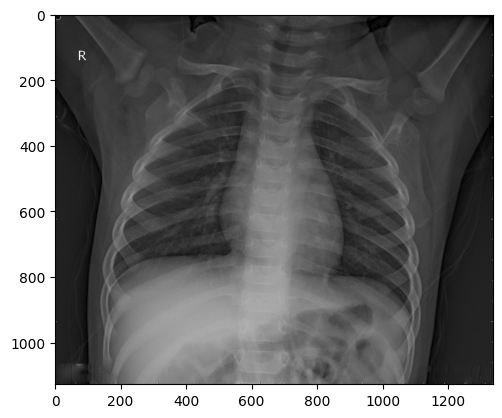

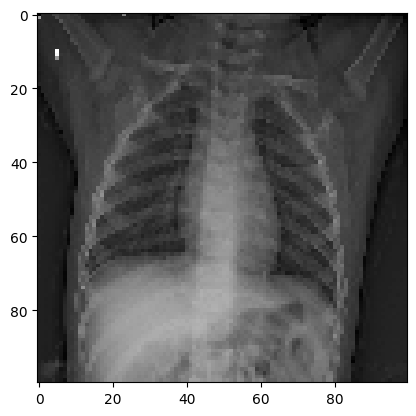

In [43]:
# converting the images into grayscale
for i in CATEGORIES:
    path=os.path.join(DataDir,i)
    for img in os.listdir(path):
        img_array=cv2.imread(os.path.join(path,img),cv2.IMREAD_GRAYSCALE)
        plt.imshow(img_array,cmap='gray')
        plt.show()
        break
    break
new_array=cv2.resize(img_array,(img_size,img_size))
plt.imshow(new_array,cmap='gray')
plt.show()

In [44]:
training_data=[]
# defining the function for training data according to the categories converting the images into gray scale with resizing the image into 100 x 100
# converting it into numpy arrays
def create_training_data():
    for i in CATEGORIES:

        path=os.path.join(DataDir,i)
        class_num=CATEGORIES.index(i)

        for img in os.listdir(path):
            try:
                img_array=cv2.imread(os.path.join(path,img),cv2.IMREAD_GRAYSCALE)
                new_array=cv2.resize(img_array,(img_size,img_size))
                training_data.append([new_array,class_num])

            except Exception as e:
                pass
create_training_data()
print(len(training_data))

5226


In [45]:
import random
random.shuffle(training_data)
for sample in training_data[:10]:
    print(sample)

[array([[29, 51, 64, ...,  0,  0,  0],
       [22, 45, 60, ...,  0,  0,  0],
       [19, 40, 55, ...,  0,  0,  0],
       ...,
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0]], dtype=uint8), 0]
[array([[ 17,  11,  37, ..., 174, 189, 184],
       [ 13,  31,  38, ..., 169, 191, 194],
       [ 15,  32,  39, ..., 175, 176, 186],
       ...,
       [ 15,  13,  11, ..., 155, 185, 181],
       [ 15,  13,  11, ..., 149, 176, 168],
       [ 15,  13,  11, ..., 136, 171, 181]], dtype=uint8), 1]
[array([[ 68,  71,  73, ...,  36,  35,  23],
       [ 68,  71,  73, ...,  30,  32,  25],
       [ 70,  72,  74, ...,  40,  41,  39],
       ...,
       [ 25,  19,  52, ...,  86, 142, 170],
       [ 19,  19,  56, ..., 100, 127, 154],
       [ 23,  15,  58, ...,  73, 113, 173]], dtype=uint8), 1]
[array([[ 15,  16,  14, ...,   4,   7,   6],
       [ 16,  16,  12, ...,   5,   5,  10],
       [ 13,  17,  16, ...,   6,   6,   6],
       ...,
      

In [46]:
X=[]
y=[]
# spliting the features and labels
for features,label in training_data:
    X.append(features)
    y.append(label)
print(X[0].reshape(-1,img_size,img_size,1))
y = np.array(y)
X = np.array(X).reshape(-1,img_size,img_size,1)


[[[[29]
   [51]
   [64]
   ...
   [ 0]
   [ 0]
   [ 0]]

  [[22]
   [45]
   [60]
   ...
   [ 0]
   [ 0]
   [ 0]]

  [[19]
   [40]
   [55]
   ...
   [ 0]
   [ 0]
   [ 0]]

  ...

  [[ 0]
   [ 0]
   [ 0]
   ...
   [ 0]
   [ 0]
   [ 0]]

  [[ 0]
   [ 0]
   [ 0]
   ...
   [ 0]
   [ 0]
   [ 0]]

  [[ 0]
   [ 0]
   [ 0]
   ...
   [ 0]
   [ 0]
   [ 0]]]]


In [47]:
validation_data=[]
def create_validating_data():
    for i in CATEGORIES:

        path=os.path.join(VAL_PATH,i)
        class_num=CATEGORIES.index(i)

        for img in os.listdir(path):
            try:
                img_array=cv2.imread(os.path.join(path,img),cv2.IMREAD_GRAYSCALE)
                new_array=cv2.resize(img_array,(img_size,img_size))
                validation_data.append([new_array,class_num])

            except Exception as e:
                pass
create_validating_data()
print(len(validation_data))
import random
random.shuffle(validation_data)
for sample in validation_data[:10]:
    print(sample)

16
[array([[64, 63, 64, ..., 97, 93, 93],
       [51, 52, 50, ..., 90, 92, 90],
       [39, 41, 44, ..., 96, 86, 86],
       ...,
       [16, 51, 78, ...,  2,  2,  6],
       [28, 56, 80, ...,  2,  1,  8],
       [35, 61, 87, ...,  2, 10,  7]], dtype=uint8), 1]
[array([[ 13,  24,  31, ...,   0,   0,   0],
       [ 12,  24,  96, ...,   0,   0,   0],
       [ 11, 254, 163, ...,   0,   0,   0],
       ...,
       [  0,  19,  28, ...,   0,   0,   0],
       [  0,  20,  27, ...,   0,   0,   0],
       [  0,  18,  28, ...,   0,   0,   0]], dtype=uint8), 1]
[array([[ 0,  5, 16, ..., 79, 47, 29],
       [ 0,  3, 15, ..., 78, 47, 27],
       [ 0,  3, 16, ..., 77, 52, 25],
       ...,
       [ 1,  1,  0, ...,  2,  2,  2],
       [ 1,  1,  0, ...,  1,  2,  2],
       [ 1,  1,  1, ...,  2,  2,  2]], dtype=uint8), 1]
[array([[0, 1, 3, ..., 0, 0, 0],
       [0, 0, 2, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 

In [48]:
X_val=[]
y_val=[]
for features,label in validation_data:
    X_val.append(features)
    y_val.append(label)
y_val = np.array(y_val)
X_val=np.array(X_val).reshape(-1,img_size,img_size,1)

In [49]:
# importing the library for training the model and adding the neural network layers
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense,Dropout,Activation,Flatten, Conv2D,MaxPooling2D
import pickle
# Pixels value ranges from 0 to 255, 0 means black, 255 means white....
# In order to scale it down to a scale of 0 to 1, we are performing this step
X = X/255.0
x_val = X_val/255.0
print(X.shape)
print(x_val.shape)


(5226, 100, 100, 1)
(16, 100, 100, 1)


In [50]:
# intializing the neural network layer for training the model
model= Sequential()

model.add(Conv2D(64,(3,3),input_shape=X.shape[1:]))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(.2))

model.add(Conv2D(128,(3,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(.2))

model.add(Conv2D(256,(3,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(.2))

model.add(Flatten())
model.add(Dense(64))

model.add(Dropout(.5))
model.add(Dense(1))
model.add(Activation('sigmoid'))
model.summary()
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
# fittting the model with 10 epochs and using the validation data we have created
model.fit(X,y,batch_size=4,epochs=10,validation_data=(x_val, y_val))


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 98, 98, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 98, 98, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 47, 47, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 47, 47, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 21, 21, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 21, 21, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │     1,638,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,008,193 (7.66 MB)

 Trainable params: 2,008,193 (7.66 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.8390 - loss: 0.4074 - val_accuracy: 0.8750 - val_loss: 0.3476
Epoch 2/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9415 - loss: 0.1598 - val_accuracy: 0.9375 - val_loss: 0.1880
Epoch 3/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9574 - loss: 0.1231 - val_accuracy: 0.7500 - val_loss: 1.1225
Epoch 4/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9609 - loss: 0.0996 - val_accuracy: 1.0000 - val_loss: 0.0422
Epoch 5/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9707 - loss: 0.0828 - val_accuracy: 0.8125 - val_loss: 0.2322
Epoch 6/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9675 - loss: 0.0770 - val_accuracy: 0.9375 - val_loss: 0.1488
Epoch 7/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9775 - loss: 0.0650 - val_accuracy: 1.0000 - val_loss: 0.0066
Epoch 8/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9771 - loss: 0.0602 -

In [53]:
model.save("cnn_xray_model.keras")

In [54]:
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.models import load_model
CATEGORIES = ["NORMAL", "PNEUMONIA"]

In [55]:
# function for preparing the image for predicting the class
def prepare(image):
    img_size=100
    #img_array=cv2.imread(image,cv2.IMREAD_GRAYSCALE)
    img=tf.keras.preprocessing.image.load_img(image, color_mode='grayscale', target_size=(img_size,img_size))
    new_array=tf.keras.preprocessing.image.img_to_array(img)

    return new_array.reshape(-1,img_size,img_size,1)
model = tf.keras.models.load_model("/kaggle/working/cnn_xray_model.keras")

**We will take actual pneumonia case in image and check the result**

In [67]:
image=r'/kaggle/input/x-ray-dataset/X Ray Dataset/chest_xray-20250726T110654Z-1-001/chest_xray/test/PNEUMONIA/person100_bacteria_475.jpeg'

In [68]:
prediction=model.predict([prepare(image)/255.0])
print(prediction)
print(round(prediction[0][0]))
print(CATEGORIES[int(round(prediction[0][0]))])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
[[0.99312145]]
1
PNEUMONIA


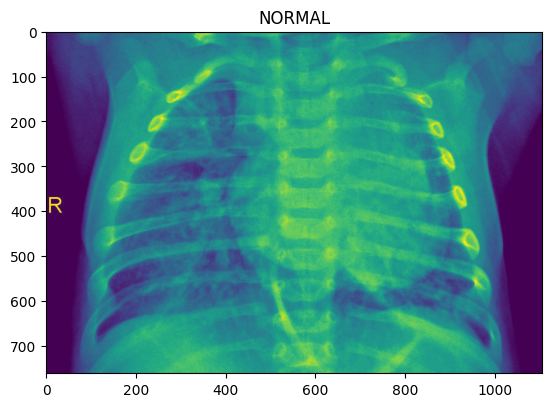

In [69]:
img=mpimg.imread(image)
imgplot=plt.imshow(img)
plt.title(CATEGORIES[int(prediction[0][0])])
plt.show()

In [70]:
# importing necessary libraries
import os
import cv2
import numpy as np
import tensorflow as tf
from keras.models import load_model

# set the path for test data
test_dir = "/kaggle/input/x-ray-dataset/X Ray Dataset/chest_xray-20250726T110654Z-1-001/chest_xray/test"

# define categories
CATEGORIES = ["NORMAL", "PNEUMONIA"]

# set image size
img_size = 100

# load the saved model
model = load_model('/kaggle/working/cnn_xray_model.keras')

# initialize lists for storing test data
X_test = []
y_test = []

# loop through the test data directory and extract the images and their labels
for category in CATEGORIES:
    path = os.path.join(test_dir, category)
    class_num = CATEGORIES.index(category)
    for img in os.listdir(path):
        try:
            img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
            new_array = cv2.resize(img_array, (img_size, img_size))
            X_test.append(new_array)
            y_test.append(class_num)
        except Exception as e:
            pass

# convert test data to numpy arrays
X_test = np.array(X_test).reshape(-1, img_size, img_size, 1)
y_test = np.array(y_test)

# normalize test data
X_test = X_test / 255.0

# calculate test accuracy
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)

# print test accuracy
print('Test accuracy:', test_acc)


20/20 - 2s - 80ms/step - accuracy: 0.7628 - loss: 1.1339
Test accuracy: 0.7628205418586731
